# Universes

A universe is a collection of cells. At a minimum, there must be one "root" universe, which gets passed to `openmc.Geometry(root)`. But you can also use universes to repeat a collection of cells multiple times throughout a geometry. Other reasons you might create a universe are to leverage helper routines in OpenMC that will streamline geometry setup. Here, we will explore some basic features of universes and reinforce concepts as to how neutrons "see" boundary conditions on different surfaces as they walk through the geometry.

We'll start by making a simple universe - say, an infinite region of space divided into four quadrants, each with a different material. For illustration, let's fill each quadrant with a different mixture of two base materials, material A and material B.

In [1]:
import openmc

In [2]:
model = openmc.Model()

mat_a = openmc.Material()
mat_a.add_element('U', 1.0, enrichment=4.0)
mat_a.add_element('O', 2.0)
mat_a.set_density('g/cc', 11.0)

mat_b = openmc.Material()
mat_b.add_element('H', 2.0)
mat_b.add_element('O', 1.0)
mat_b.set_density('g/cc', 1.0)

q1 = openmc.Material.mix_materials([mat_a, mat_b], [0.1, 0.9])
q2 = openmc.Material.mix_materials([mat_a, mat_b], [0.2, 0.8])
q3 = openmc.Material.mix_materials([mat_a, mat_b], [0.3, 0.7])
q4 = openmc.Material.mix_materials([mat_a, mat_b], [0.5, 0.5])

In [3]:
horizontal = openmc.XPlane(x0 = 0)
vertical = openmc.YPlane(y0 = 0)

quad1_cell = openmc.Cell(region=+horizontal & +vertical, fill=q1)
quad2_cell = openmc.Cell(region=+horizontal & -vertical, fill=q2)
quad3_cell = openmc.Cell(region=-horizontal & -vertical, fill=q3)
quad4_cell = openmc.Cell(region=-horizontal & +vertical, fill=q4)

universe = openmc.Universe()
universe.add_cells([quad1_cell, quad2_cell, quad3_cell, quad4_cell])

Let's plot our universe to confirm we know what we've built. Note that because the cells are infinite, that the universe extends to infinity.

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

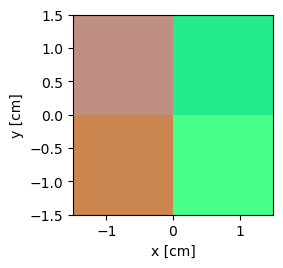

In [4]:
universe.plot(width=(3, 3))

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

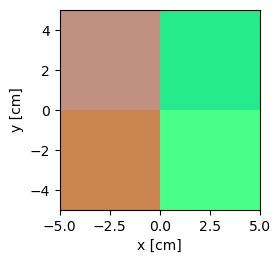

In [5]:
universe.plot(width=(10, 10))

Now let's suppose that I want to fill this universe into an enclosing cell, a cylinder of radius 5 cm. Let's first create this cylinder, and then we will fill it with our universe.

In [6]:
big_cylinder = openmc.ZCylinder(x0=0.0, y0=0.0, r=5.0)
big_cell = openmc.Cell(region = -big_cylinder, fill=universe)

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

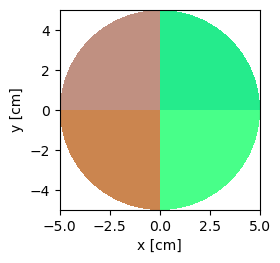

In [7]:
big_cell.plot(width=(10.0, 10.0))

We can see that our `big_cell`, the large cylinder, has been filled with the universe we declared earlier. Let's increase the complexity a bit to understand how this filling works. What if we had made our universe so that the intersection of the `horizontal` and `vertical` surfaces occurred at (1, 1) instead of (0, 0)?

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

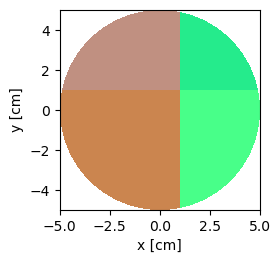

In [8]:
horizontal.x0 = 1
vertical.y0 = 1

big_cell.plot(width=(10.0, 10.0))

We see that when we fill a universe inside of another cell, that there's (by default) no transformation of coordinates. It's as if we are directly underlaying the filled universe into a "higher-up" cell. You can shift the position of the universe (_without_ actually modifying the filling universe itself) filling a cell with the `Cell.translation` attribute. 

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

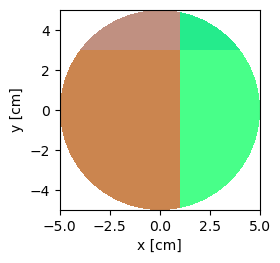

In [9]:
big_cell.translation = [0.0, 2.0, 0.0]
big_cell.plot(width=(10.0, 10.0))

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

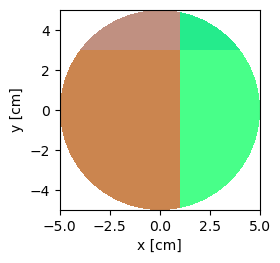

In [10]:
big_cell.plot(width=(10.0, 10.0))

There are similar adjustments you can make (_without_ actually changing the filling universe itself), like rotations. The `Cell.rotation` method lists the rotation angles (in degrees) for rotations about the x, y, and z axes.

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

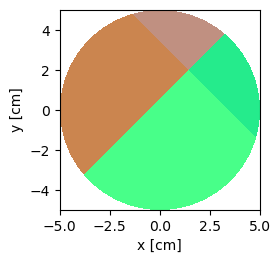

In [11]:
big_cell.rotation = [0, 0, -45]
big_cell.plot(width=(10.0, 10.0))

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

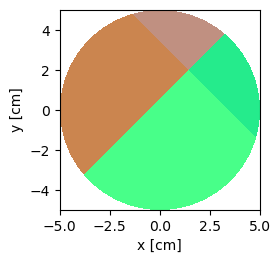

In [12]:
big_cell.plot(width=(10.0, 10.0))

If we wanted to run transport on this overall geometry, we would need to assign some universe to the root universe. We could create a universe consisting of a single cell (`big_cell`), or OpenMC can also construct for us a universe behind-the-scenes if we just pass in the list of cells that would be in the root universe.

In [13]:
model.geometry = openmc.Geometry([big_cell])

# same as doing
root_universe = openmc.Universe(cells=[big_cell])
model.geometry = openmc.Geometry(root_universe)

Then, let's assign some simple settings and try to run.

In [14]:
model.settings = openmc.Settings()
model.settings.particles = 100
model.settings.inactive = 10
model.settings.batches = 20

In [15]:
#model.run()

When we try and run, we get an error: `No boundary conditions were applied to any surfaces!` Let's think about the history of a neutron which is initially sampled somewhere inside the geometry but manages to make it to the edge of the cylinder. The neutron may try to cross that cylinder, which is by default a `transmission` boundary type (because we did not set it ourselves). The neutron will try to cross the surface, but because there is no universe or cell on the other side, OpenMC will not be able to sample the next material's cross sections to continue the transport. The fix is that we should set a boundary condition to the `big_cylinder` (the _surface_).

In [16]:
big_cylinder.boundary_type = 'vacuum'
model.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

PosixPath('/Users/anovak/projects/openmc-education/universes-lattices-02/statepoint.20.h5')

## Materials, Cells, etc. Outside the Root Universe

Let's suppose we built our universe in such a way that two of our quadrants are completely cut off by the enclosing cylinder. We can do this a few different ways, but let's just change the `horizontal` and `vertical` planes in our initial model so that they intersect at (-10, 0, 0), which will be outside our cylinder.

In [17]:
horizontal.x0 = -10
vertical.y0 = 0.0

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

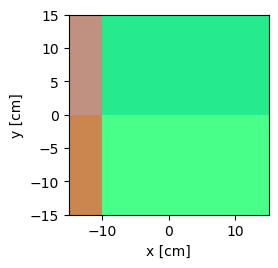

In [18]:
universe.plot(width=(30.0, 30.0))

Let's now plot our geometry, undoing the rotation we added before to make this simpler to understand. You can see that we don't see the materials in the 2nd and 3rd quadrant at all - they've been completely chopped off. However, those materials still exist in the OpenMC model - neutrons will just never reach them. The same idea applies to the cells - the `quad2_cell` and `quad3_cell` still exist in memory, but neutrons never reach there.

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

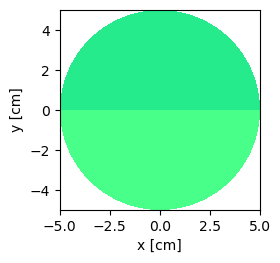

In [19]:
big_cell.rotation = [0, 0, 0]
big_cell.translation = [0, 0, 0]
root_universe.plot(width=(10.0, 10.0))

In [20]:
all_materials = model.geometry.get_all_materials()
print(all_materials)

{3: Material
	ID             =	3
	Name           =	(0.1)-(0.9)
	Temperature    =	None
	Density        =	2.314507220360796 [g/cm3]
	Volume         =	None [cm^3]
	Depletable     =	True
	S(a,b) Tables  
	Nuclides       
	U234           =	1.206371336604935e-05 [ao]
	U235           =	0.0013496893451669521 [ao]
	U238           =	0.03196539804932207 [ao]
	U236           =	6.18222547825592e-06 [ao]
	O16            =	0.36579422   [ao]
	O17            =	0.00013896666666666667 [ao]
	O18            =	0.0007334799999999999 [ao]
	H1             =	0.5999065559999999 [ao]
	H2             =	9.344399999999998e-05 [ao]
, 4: Material
	ID             =	4
	Name           =	(0.2)-(0.8)
	Temperature    =	None
	Density        =	3.5402449541048098 [g/cm3]
	Volume         =	None [cm^3]
	Depletable     =	True
	S(a,b) Tables  
	Nuclides       
	U234           =	2.412742673209871e-05 [ao]
	U235           =	0.002699378690333905 [ao]
	U238           =	0.06393079609864416 [ao]
	U236           =	1.2364450956511847e-05 

In [21]:
all_cells = model.geometry.get_all_cells()
print(all_cells)

{5: Cell
	ID             =	5
	Name           =	
	Fill           =	1
	Region         =	-3
	Rotation       =	[0 0 0]
	Translation    =	[0 0 0]
	Volume         =	None
, 1: Cell
	ID             =	1
	Name           =	
	Fill           =	Material 3
	Region         =	(1 2)
	Rotation       =	None
	Temperature    =	None
	Density        =	None
	Translation    =	None
	Volume         =	None
, 2: Cell
	ID             =	2
	Name           =	
	Fill           =	Material 4
	Region         =	(1 -2)
	Rotation       =	None
	Temperature    =	None
	Density        =	None
	Translation    =	None
	Volume         =	None
, 3: Cell
	ID             =	3
	Name           =	
	Fill           =	Material 5
	Region         =	(-1 -2)
	Rotation       =	None
	Temperature    =	None
	Density        =	None
	Translation    =	None
	Volume         =	None
, 4: Cell
	ID             =	4
	Name           =	
	Fill           =	Material 6
	Region         =	(-1 2)
	Rotation       =	None
	Temperature    =	None
	Density        =	None
	Translati

## Boundary Conditions When Filled

When a universe is filled inside a cell, the boundary conditions on all the various surfaces are unaffected - to understand the boundary conditions in your problem, just think about the process of a neutron walk. Whenever that neutron crosses a surface, that surface's boundary condition will be applied to the neutron. To explore this concept, let's make our filling universe finite in extent. We can do this by placing our original `universe` inside a surface to create a new cell.

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

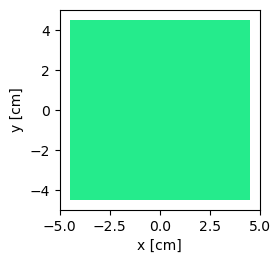

In [22]:
rectangle = openmc.model.RectangularPrism(width=9, height=9, boundary_type='vacuum')
(-rectangle).plot(width=(10, 10))

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

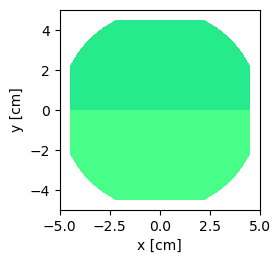

In [23]:
big_universe = openmc.Universe(cells=[big_cell])
new_cell = openmc.Cell(region=-rectangle, fill=big_universe)
#big_cell.fill = finite_universe
new_cell.plot(width=(10, 10))

In [24]:
model.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

PosixPath('/Users/anovak/projects/openmc-education/universes-lattices-02/statepoint.20.h5')

Our model has correctly defined all boundary conditions - any time a neutron would leave the rectangular prism surface defining our square, the neutron encounters a vacuum boundary condition. If a neutron instead first passes through the cylinder, it also sees a vacuum boundary condition. So, our model effectively has the following boundaries.

<center><img src="bcs.png" alt="drawing" width="=100"/></center>

If the boundary conditions on `rectangle` had instead been `transmission`, then we would have a problem - the neutron would try to cross the red surfaces, but OpenMC would not be able to find any material on the other side.

We'll use this universe again later - let's remove the translation so that our quadrants have an origin at (0, 0).

In [25]:
horizontal.x0 = 0
vertical.y0 = 0

# Lattices

Lattices are a convenient way to (i) repeat a universe multiple times in space, while (ii) automatically translating that universe's origin to different positions in space. 

In this section, we will build one of the assemblies from the BEAVRS benchmark. This is a Pressurized Water Reactor (PWR) assembly with fuel pins, guide tubes, and borosilicate glass burnable poisons. A diagram of the assembly is plotted below.

<center><img src="assembly_diagram.png" alt="drawing" width="=150"/></center>

In order to build this geometry, we will need to define four universes -- one for a fuel pin (the lilac square with nothing indicated in them), one for a poison pin (B), one for an instrumentation pin (I), and one for a guide tube (G). 

Before we can discuss lattices, we need to build the materials, cells, and universes for each of these.

### Fuel pin universe

To build our fuel pin universe, we will require three materials. Note that we treat the helium gap as vacuum by setting `fill=None` (which we don't have to write out since it's the default already).

In [26]:
uo2 = openmc.Material(name='uo2')
uo2.add_element('U', 1.0, enrichment=3.0)
uo2.add_nuclide('O16', 2.0)
uo2.set_density('g/cm3', 10.0)

zirconium = openmc.Material(name='zirconium')
zirconium.add_element('Zr', 1.0)
zirconium.set_density('g/cm3', 6.6)

water = openmc.Material(name='water')
water.add_nuclide('H1', 2)
water.add_nuclide('O16', 1)
water.set_density('g/cm3', 0.7)
water.add_s_alpha_beta('c_H_in_H2O')

In [27]:
pitch = 1.26
fuel_or = openmc.ZCylinder(r=0.39)
clad_ir = openmc.ZCylinder(r=0.40)
clad_or = openmc.ZCylinder(r=0.46)

fuel = openmc.Cell(fill=uo2, region=-fuel_or)
gap = openmc.Cell(fill=None, region=+fuel_or & -clad_ir)
clad = openmc.Cell(fill=zirconium, region=+clad_ir & -clad_or)
moderator = openmc.Cell(fill=water, region=+clad_or)

fuel_pin = openmc.Universe(cells=[fuel, gap, clad, moderator])

When building a complex geometry, it is helpful to plot each universe as you go along. Let's plot this pincell now. 

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

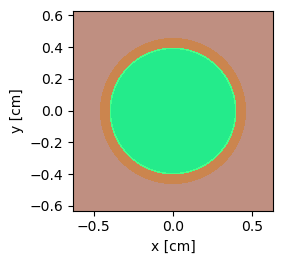

In [28]:
fuel_pin.plot(width=(pitch, pitch))

### Guide tube universe
A guide tube is an annulus of zirconium within which water flows. These tubes are used to receive control rods.

In [29]:
guide_clad_ir = openmc.ZCylinder(r=0.56)
guide_clad_or = openmc.ZCylinder(r=0.60)

guide_inner = openmc.Cell(fill=water, region=-guide_clad_ir)
guide_clad = openmc.Cell(fill=zirconium, region=+guide_clad_ir & -guide_clad_or)
guide_outer = openmc.Cell(fill=water, region=+guide_clad_or)

guide_tube = openmc.Universe(cells=[guide_inner, guide_clad, guide_outer])

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

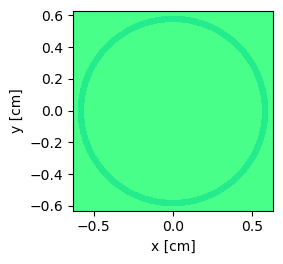

In [30]:
guide_tube.plot(width=(pitch, pitch), color_by='material')

### Pyrex burnable poison universe
The burnable absorber universe is a series of annular cylinders enclosing an annular pyrex layer. The geometry is defined as follows:

- R < 0.21 cm, void
- 0.21 cm < R < 0.23 cm, zirconium
- 0.23 cm < R < 0.24 cm, void
- 0.24 cm < R < 0.43 cm, pyrex
- 0.43 cm < R < 0.44 cm, void
- 0.44 cm < R < 0.48 cm, zirconium
- 0.48 cm < R < 0.56 cm, water
- 0.56 cm < R < 0.60 cm, zirconium
- 0.60 cm < R, water

In [31]:
pyrex = openmc.Material(name='pyrex')
pyrex.add_element('B', 0.49)
pyrex.add_element('O', 4.7)
pyrex.add_element('Al', 0.17)
pyrex.add_element('Si', 1.8)
pyrex.set_density('g/cm3', 2.26)

To create the geometry, we're going to use some advanced features. First, we'll use a [list comprehension](https://docs.python.org/3/tutorial/datastructures.html#list-comprehensions), which is a way of creating a list in Python that embeds a for loop.

In [32]:
radii = [0.21, 0.23, 0.24, 0.43, 0.44, 0.48, 0.56, 0.60]
cyls = [openmc.ZCylinder(r=r) for r in radii]

To create this pin, we're going to use a function provided by OpenMC specifically for this purpose, [`openmc.model.pin`](https://docs.openmc.org/en/stable/pythonapi/model.html).

In [33]:
mats = [None, zirconium, None, pyrex, None, zirconium, water, zirconium, water]
burn = openmc.model.pin(cyls, mats)

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

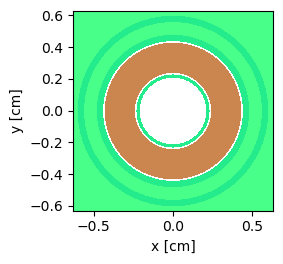

In [34]:
burn.plot(width=(pitch, pitch), color_by='material')

## Lattices in OpenMC

OpenMC has `RectLattice` and `HexLattice` objects, to place universes within a rectangular or hexagonal lattice, respectively. Lattices can be built in 2-D or 3-D. For our fuel assembly, we will use a 2-D `RectLattice` (infinite in the vertical direction).

When creating a rectangular lattice, we need to define:

- The lower-left coordinates of the lattice (`.lower_left`)
- The size of each lattice element (`.pitch`)
- The arrangement of universes (`.universes`)
- (optionally) A universe that is used outside of the defined region (`.outer`); this is only relevant if the lattice is filled inside another cell whose boundary allows some "open space" outside the nominal edges of the lattice and the surface defining the cell.

In [35]:
lattice = openmc.RectLattice()

# Define the lower-left coordinates and size of lattice elements
lattice.lower_left = (0., 0.)
lattice.pitch = (pitch, pitch)

# Now we specify what is actually inside the lattice.  This 2D lattice will be a
# list of lists like
# lattice.universes = [ [a1, a2, ...], [b1, b2, ...], ...]
# The inner lists specify columns from left to right.  The outer lists specify
# rows from top to bottom.
lattice.universes = [
    [fuel_pin,   fuel_pin],
    [guide_tube, fuel_pin]
]

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

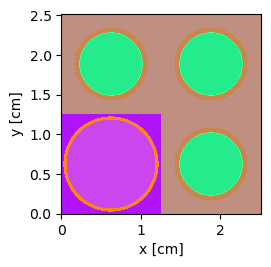

In [36]:
example_univ = openmc.Universe(cells=[openmc.Cell(fill=lattice)])
example_univ.plot(width=(2*pitch, 2*pitch), origin=(pitch, pitch, 0))

By default, the extent of a lattice only covers the actual lattice "slots." If we try to plot our geometry but with a wider width (so that we are including regions of space outside our 2x2 lattice), OpenMC will throw an error.

In [37]:
#example_univ.plot(width=(3*pitch, 3*pitch), origin=(pitch, pitch, 0))

If we ever want to plot or have neutrons track through regions outside the lattice, but which are not also "chopped off" by some containing cell, we can specify the `.outer` parameter for the lattice. As an example, let's set the outer universe to an infinite universe of water.

In [38]:
all_water = openmc.Universe()
all_water.add_cell(openmc.Cell(fill=water))
lattice.outer = all_water

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

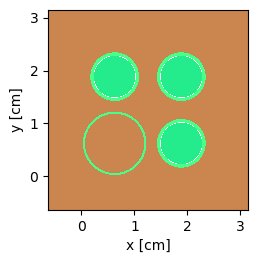

In [39]:
example_univ.plot(width=(3*pitch, 3*pitch), origin=(pitch, pitch, 0), color_by='material')

## What exactly does `outer` mean?

To get a better sense of what the outer universe does, let's change the outer universe to the quadrant universe we created earlier. We could also try with a `burn` universe.

In [40]:
lattice.outer = universe

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

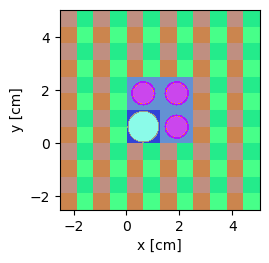

In [41]:
example_univ.plot(width=(6*pitch, 6*pitch), origin=(pitch, pitch, 0))

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

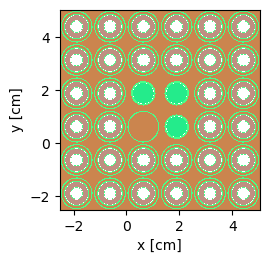

In [42]:
lattice.outer = burn
example_univ.plot(width=(6*pitch, 6*pitch), origin=(pitch, pitch, 0), color_by='material')

# The BEAVRS Assembly

<img src="assembly_diagram.png" alt="drawing" width="350"/>

To make things a little easier, we'll create lists of (row, column) positions for the guide tubes and burnable poison rods:

In [43]:
guide_tube_positions = [
    (2, 5), (2, 8), (2, 11),
    (5, 2), (5, 5), (5, 8), (5, 11), (5, 14),
    (8, 2), (8, 5), (8, 8), (8, 11), (8, 14),
    (11, 2), (11, 5), (11, 8), (11, 11), (11, 14),
    (14, 5), (14, 8), (14, 11)
]

burn_positions = [(3, 3), (3, 13), (13, 3), (13, 13)] 

In [44]:
lattice = openmc.RectLattice()

lattice.pitch = (pitch, pitch)
lattice.outer = all_water

assembly_pitch = 17*pitch
lattice.lower_left = (-assembly_pitch/2, -assembly_pitch/2)

lattice.universes = [[fuel_pin] * 17] * 17

# Replace the fuel pins with guide tubes in appropriate places
for row, col in guide_tube_positions:
    lattice.universes[row, col] = guide_tube
    
# Replace the fuel pins with burnable absorber pins in appropriate places
for row, col in burn_positions:
    lattice.universes[row, col] = burn

Now we just have to add the boundary conditions and root universe to finish the geometry. Because each of our cells we used in constructing the lattice uses `transmission` boundary conditions (the default), we need to place the lattice inside some other containing cell, which has boundary conditions.

In [45]:
outer_surface = openmc.model.RectangularPrism(width=assembly_pitch, height=assembly_pitch, boundary_type='reflective')
box = openmc.Cell(region=-outer_surface, fill=lattice)

In [46]:
model.geometry = openmc.Geometry([box])

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

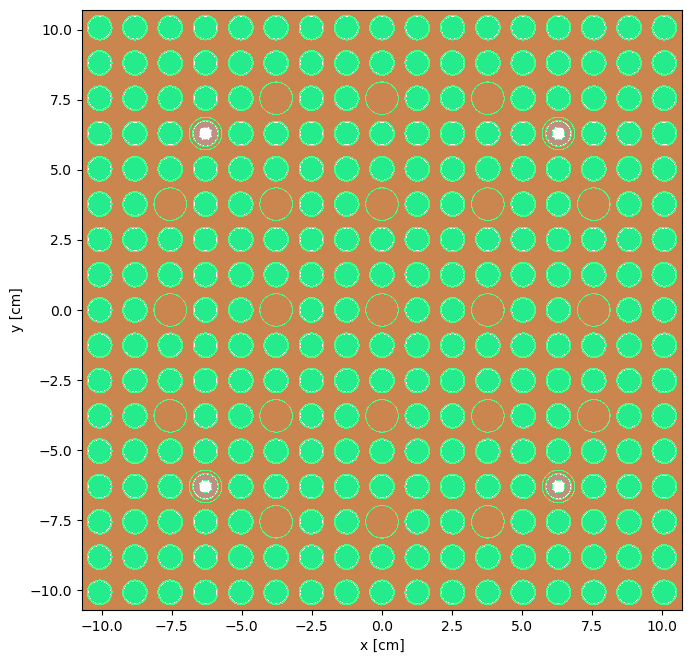

In [47]:
model.geometry.plot(width=(17*pitch, 17*pitch), origin=(0, 0, 0), 
          color_by='material', pixels=[600,600])

To run this input file, now all we need to do is specify some run settings.

In [48]:
model.settings.batches = 50
model.settings.inactive = 10
model.settings.particles = 1000
model.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

PosixPath('/Users/anovak/projects/openmc-education/universes-lattices-02/statepoint.50.h5')

## Hexagonal Lattices
OpenMC also allows you to define hexagonal lattices. They are a little trickier, but as we'll see there are some helper methods that demystify how to assign universes.

We need to set the center of the lattice, the pitch, an outer universe (which is applied to all lattice elements outside of those that are defined), and a list of universes. Let's start with the easy ones first. Note that for a 2-D lattice, we only need to specify a single number for the pitch. We also need to state the `center` for the `HexLattice`.

In [49]:
hex_lat = openmc.HexLattice()
hex_lat.center = (0., 0.)
hex_lat.pitch = [pitch]
hex_lat.outer = all_water

Now we need to set the universes property on our lattice. It needs to be set to a list of lists of Universes, where each list of Universes corresponds to a ring of the lattice. The rings are ordered from outermost to innermost, and within each ring the indexing starts at the "top". To help visualize the proper indices, we can use the `show_indices()` helper method.

In [50]:
print(hex_lat.show_indices(num_rings=3))

            (0, 0)
      (0,11)      (0, 1)
(0,10)      (1, 0)      (0, 2)
      (1, 5)      (1, 1)
(0, 9)      (2, 0)      (0, 3)
      (1, 4)      (1, 2)
(0, 8)      (1, 3)      (0, 4)
      (0, 7)      (0, 5)
            (0, 6)


Let's set up a lattice where the first element in each ring is the guide tube universe and all other elements are regular fuel pin universes. From the diagram above, we see that the outer ring has 12 elements, the middle ring has 6, and the innermost degenerate ring has a single element.

In [51]:
outer_ring = [guide_tube] + [fuel_pin]*11
middle_ring = [guide_tube] + [fuel_pin]*5
inner_ring = [guide_tube]
hex_lat.universes = [outer_ring, middle_ring, inner_ring]

print(hex_lat)

HexLattice
	ID             =	13
	Name           =	
	Orientation    =	y
	# Rings        =	3
	# Axial        =	None
	Center         =	(0.0, 0.0)
	Pitch          =	[1.26]
	Outer          =	10
	Universes      
  6
 5 5
5 6 5
 5 5
5 6 5
 5 5
5 5 5
 5 5
  5


Now let's put our lattice inside a circular cell.

In [52]:
outer_surface = openmc.ZCylinder(r=4.0)
main_cell = openmc.Cell(fill=hex_lat, region=-outer_surface)

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

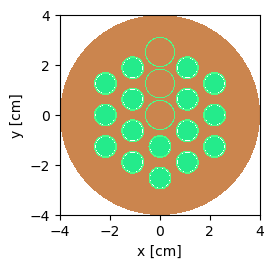

In [53]:
main_cell.plot(width=(8, 8), color_by='material')

Now let's say we want our hexagonal lattice orientated such that flat sides are parallel to the y-axis instead of the x-axis. This can be achieved by changing the orientation of the lattice from `y` to `x`:

In [54]:
hex_lat.orientation = 'x'

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

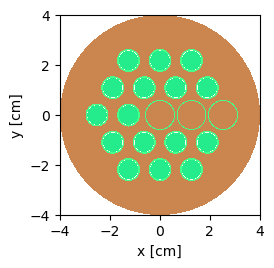

In [55]:
main_cell.plot(width=(8, 8), color_by='material')

We could also have accomplished this using the `rotation` attribute for the `main_cell`.

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

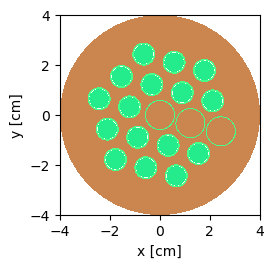

In [56]:
main_cell.rotation = [0, 0, -15]
main_cell.plot(width=(8, 8), color_by='material')

With universes, we can obtain information about all of the cells, universes, or lattices which are found at a given point. This can be helpful to understand the notion of "levels" in the geometry. In the geometry we have built, 

- level 0: the root universe, `root`
- level 1: region of space inside the cylinder (the cell, `main_cell`)
- level 2: region of space within the individual lattice elements of the `HexLattice`
- level 3: individual cells within the universes filling the `HexLattice`
- level 4: the guide tube universe, `guide_tube`
- level 5: the water cell in the guide tube universe, `guide_inner`

We can obtain this information, for a given point, by using the `find` method and passing in a point.

In [57]:
root = openmc.Universe(cells=[main_cell])
layers = root.find((0, 0, 0))
print(len(layers))

5


In [58]:
for i in layers:
    print(i, '\n')

Universe
	ID             =	14
	Name           =	
	Geom           =	CSG
	Cells          =	[26]
 

Cell
	ID             =	26
	Name           =	
	Fill           =	13
	Region         =	-25
	Rotation       =	[  0   0 -15]
	Translation    =	None
	Volume         =	None
 

(HexLattice
	ID             =	13
	Name           =	
	Orientation    =	x
	# Rings        =	3
	# Axial        =	None
	Center         =	(0.0, 0.0)
	Pitch          =	[1.26]
	Outer          =	10
	Universes      
  5 5 5
 5 5 5 5
5 5 6 6 6
 5 5 5 5
  5 5 5, (0, 0, 1)) 

Universe
	ID             =	6
	Name           =	
	Geom           =	CSG
	Cells          =	[11, 12, 13]
 

Cell
	ID             =	11
	Name           =	
	Fill           =	Material 9
	Region         =	-11
	Rotation       =	None
	Temperature    =	None
	Density        =	None
	Translation    =	None
	Volume         =	None
 

